# # DL - 지도학습 - Classification 실습

[사용 제한 안내]
> 본 실습 코드는 교육 및 학습 목적으로만 제공됩니다.

[사전 준비 사항]
- 없음

[분석 요건]
- 분석 주제 : CNN 기법을 활용하여 이미지 분류 모델 실습
- 분석 단위 : 이미지

[주요 실습 내용]
- CNN(Convolutional Neural Network)

# Random Seed 고정
- 결과 재현하기 위함

In [1]:
import tensorflow as tf

# Python, NumPy, TensorFlow Seed를 한 번에 설정
SEED = 42
tf.keras.utils.set_random_seed(SEED)

=> 딥러닝에서 난수가 사용되는 부분

| 구분       | 설명                                        |
| ----------------- | ----------------------------------------- |
| **가중치 초기화**       | 학습 시작 시 뉴런의 Weight가 무작위로 초기화              |
| **데이터 Shuffle**   | Epoch마다 학습 데이터 순서를 섞음                     |
| **Mini-Batch 구성** | Shuffle에 따라 Batch에 들어가는 데이터가 달라짐          |
| **Dropout**       | 학습할 때 임의의 뉴런을 비활성화                       |

# 데이터 준비
- 분석 데이타 : fashion_mnist
- 데이타 설명 : 28×28 흑백 의류 이미지를 이용하여 10가지 의류 종류를 분류하는 이미지 분류용 데이터셋
- 데이타 건수 : 학습 데이터	60,000장, 테스트 데이터	10,000장

데이타 불러오기

In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 데이터 불러오기
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape : (10000, 28, 28)
y_test shape : (10000,)


=> X_train shape: (60000, 28, 28) -> 세로 28, 가로 28 크기의 이미지 60,000장

데이타 확인
- X_train 데이터 확인

In [3]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

- Y_train 데이터 확인

In [4]:
y_train

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

- 이미지 (X)와 Class (Y) 시각화 확인

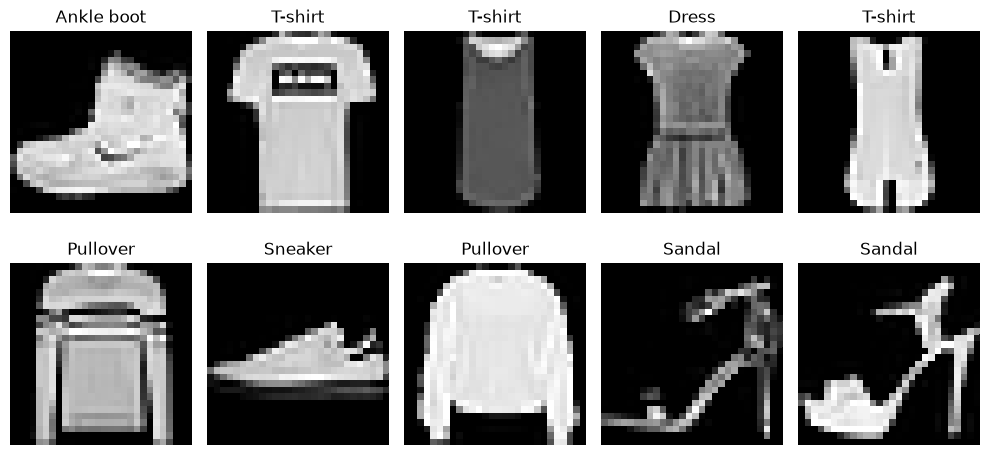

In [5]:
# Y 클래스 이름 정의
class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

# 이미지 샘플 시각화 확인
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

데이타 전처리

In [6]:
# float32 으로 변환 후 (메모리 효율화) -> Min–Max Scaling (0~1)
X_train = x_train.astype('float32') / 255.0
X_test = x_test.astype('float32') / 255.0

# CNN 입력 형태 (이미지 개수, 세로, 가로, 채널수) 로 변환
X_train = X_train.reshape(-1, 28, 28, 1)  # reshape(-1): 이미지 개수를 자동 계산, 1:흑백 이미지 채널수, (참고) 컬러 이미지 채널수: 3
X_test = X_test.reshape(-1, 28, 28, 1)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (60000, 28, 28, 1)
X_test shape : (10000, 28, 28, 1)


# CNN
- 모델 학습 및 평가

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7757 - loss: 0.6342 - val_accuracy: 0.8586 - val_loss: 0.3974
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8537 - loss: 0.4095 - val_accuracy: 0.8791 - val_loss: 0.3305
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8741 - loss: 0.3558 - val_accuracy: 0.8853 - val_loss: 0.3097
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8836 - loss: 0.3243 - val_accuracy: 0.8972 - val_loss: 0.2817
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8939 - loss: 0.2972 - val_accuracy: 0.8998 - val_loss: 0.2693
학습 시간: 9.32초


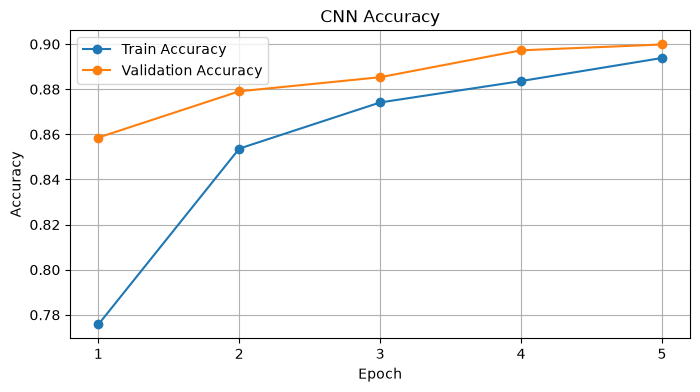

Test Loss     : 0.2871
Test Accuracy : 0.8928


In [19]:
import tensorflow as tf

# Random Seed 고정
SEED = 42
tf.keras.utils.set_random_seed(SEED)

# CNN 구조 설계, Conv2D : 2차원 이미지(세로*가로) 합성곱(Convolution) 층, (참고) 영상의 경우 Conv3D (3차원) 가 됨
cnn_model = Sequential([
    Conv2D(16, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),  # 16: 필터 개수, kernel_size:필터의 크기, input_shape: 입력 이미지 크기(세로, 가로, 채널)
    MaxPooling2D(pool_size=(2, 2)),                                              # Conv2D 결과에서 2×2 영역 단위로 Max 값 하나만 남김

    Conv2D(32, kernel_size=(3, 3), activation="relu"),                           # 두번째 합성곱층

    Flatten(),                                                                   # 3차원 (세로×가로×채널)  → 1차원 벡터로 변환

    Dense(64, activation="relu"),                                                # Fully Connected Layer 64개 뉴런
    Dropout(0.3),                                                                # 30% 뉴런 비활성화
    Dense(10, activation="softmax")                                              # 출력층, 10: 10 Class, *이진분류인 경우: Dense(1, activation="sigmoid")
])

# 모델 컴파일
cnn_model.compile(
    optimizer="adam",                                       # 가중치 수정 방법, 기본 learning_rate = 0.001
    loss="sparse_categorical_crossentropy",                 # loss 계산 방법, 다중 분류 (클래스 3개 이상) 시 Loss 함수, *이진분류인 경우 "binary_crossentropy"
    metrics=["accuracy"]                                    # 평가 지표
)

# 모델 학습
start = time.time()

history = cnn_model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,      # 검증 데이터 비율
    verbose=1                  # 진행과정 상세 출력
)
end = time.time()
print(f"학습 시간: {end - start:.2f}초")

# 학습 과정 시각화
epochs = range(1, len(history.history["accuracy"]) + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs, history.history["accuracy"], marker="o",
         label="Train Accuracy")
plt.plot(epochs, history.history["val_accuracy"], marker="o",
         label="Validation Accuracy")
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.legend()
plt.grid(True)
plt.show()


# 모델 평가 : Test Set
test_loss, test_acc = cnn_model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

- 예측 결과 시각적 확인

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 604us/step


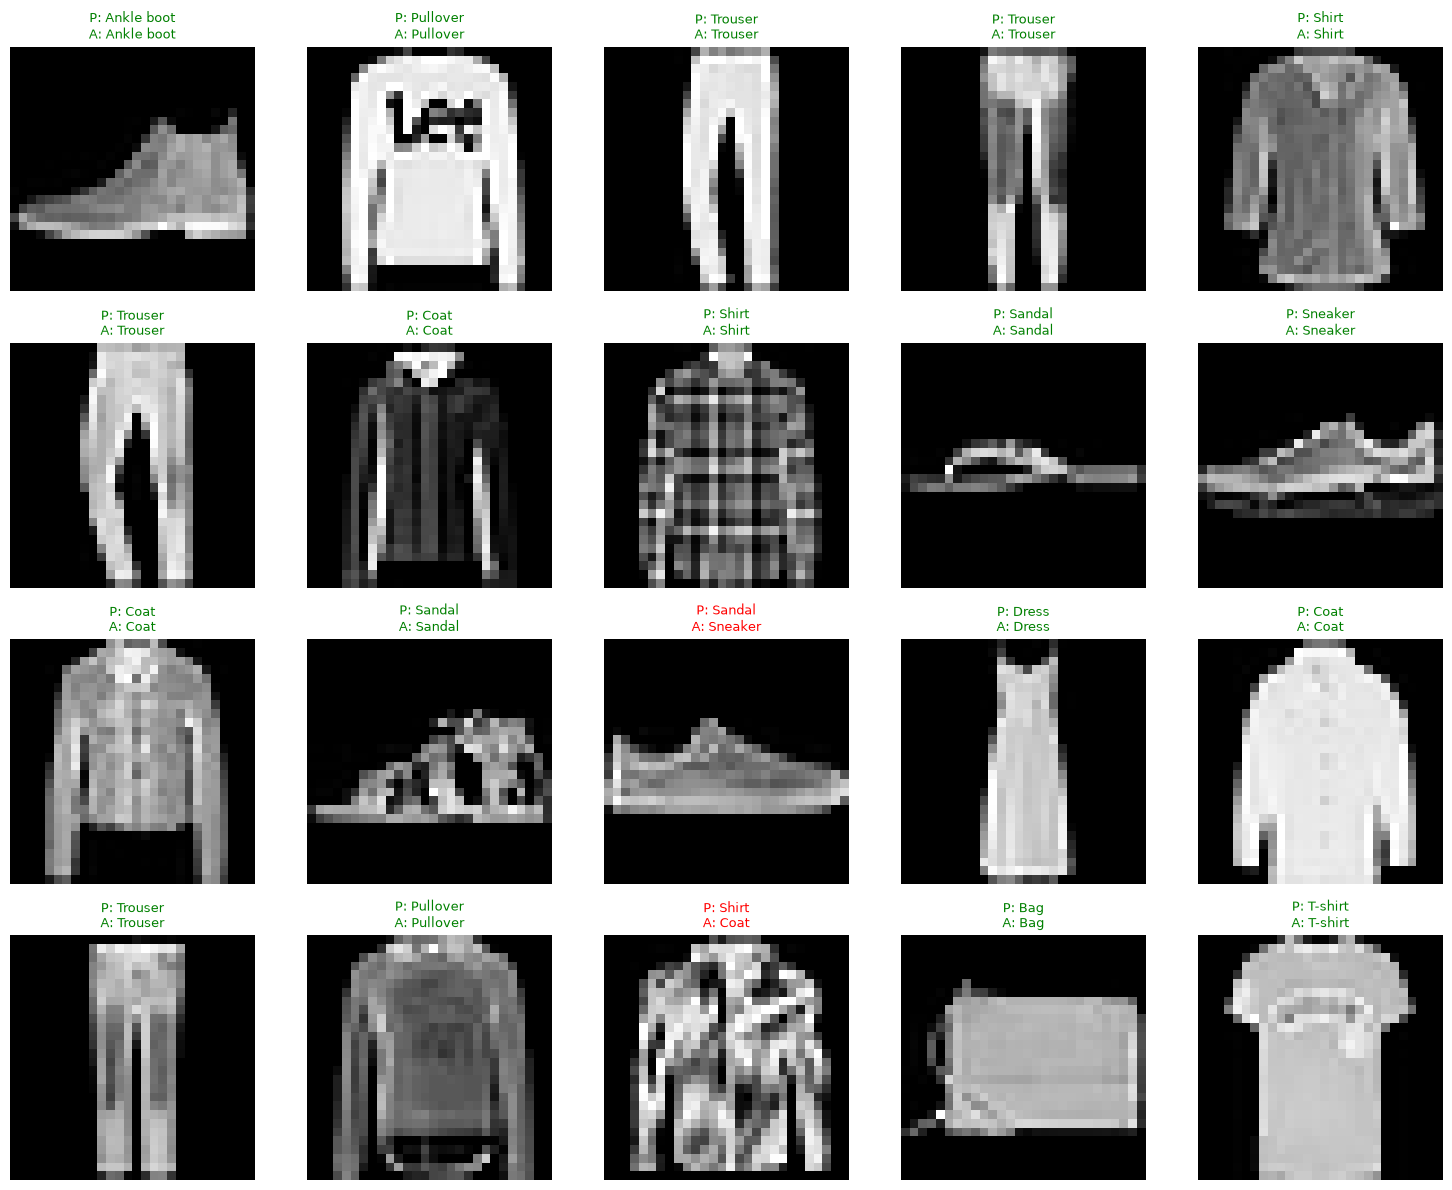

In [8]:
# 예측
y_pred_proba = cnn_model.predict(X_test)   # 예측 확률
y_pred = np.argmax(y_pred_proba, axis=1)   # 예측 클래스

# 예측 결과 샘플 확인
plt.figure(figsize=(15, 12))

for i in range(20):
    plt.subplot(4, 5, i + 1)

    plt.imshow(X_test[i].reshape(28, 28), cmap="gray")

    predicted = class_names[y_pred[i]]
    actual = class_names[y_test[i]]

    color = "green" if predicted == actual else "red"

    plt.title(f"P: {predicted}\nA: {actual}", color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

### [Self-Practice]

Q1) Dropout 비율을 변경하면서 Test accuracy 와 소요 시간(Execution Time) 을 측정하고 비교해 보세요. 예) Dropout=적용안함, 0.3, 0.5   
Q2) epochs 값을 변경하면서 Train accuracy,  Validation Accuracy, Test Accuracy가 어떻게 달라지는지 비교하세요.  예) epochs=3, 5, 10   


## Q1

### @ Epochs = 3

|Dropout|Test Accuracy|Execution Time|
|---|---|---|
|x|0.8815|5.71초|
|0.3|0.8787|5.61초|
|0.5|0.8773|5.60초|



## Q2

### @ Dropout = 0.3

|Epochs|Train|Valid|Test|
|---|---|---|---|
|3|0.8741|0.8853|0.8787|
|5|0.8939|0.8998|0.8928|
|10|0.9177|0.9117|0.9052|